In [1]:
# ============================================================
# MPG Optimizer — Analyse Exploratoire des Données
# ============================================================
# Ce notebook explore les données MPG + FBref pour :
#   1. Comprendre la distribution des joueurs et des notes
#   2. Identifier les patterns intéressants
#   3. Valider les choix de scoring dans player_rating.py
#   4. Trouver des insights pour améliorer l'optimiseur
# ============================================================

import sys
sys.path.insert(0, '..')  # Pour trouver le dossier src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Imports OK")

Matplotlib is building the font cache; this may take a moment.


✅ Imports OK


In [3]:
import os

# On se place à la racine du projet (un niveau au-dessus de notebooks/)
os.chdir('..')
print("Dossier courant :", os.getcwd())

Dossier courant : /Users/julielandrevie/Desktop/Projet MPG


In [4]:
# Chargement du dataset master (MPG + FBref croisés)
from src.data.collect import build_master_dataset
from src.analysis.player_rating import compute_ratings

# Chargement
df_raw = build_master_dataset()
print(f"Dataset chargé : {len(df_raw)} joueurs, {len(df_raw.columns)} colonnes")

# Calcul des scores
df = compute_ratings(df_raw, min_minutes=0)
print(f"Scores calculés : {df['avg_rating'].notna().sum()} joueurs scorés")
print(f"\nColonnes disponibles :")
print([c for c in df.columns])

2026-05-15 19:49:19.127 | INFO     | src.data.collect:build_master_dataset:300 - 📂 Dataset master trouvé en cache.
2026-05-15 19:49:19.137 | INFO     | src.analysis.player_rating:compute_ratings:158 - Calcul des scores pour 514 joueurs (seuil : 0 matchs)...
2026-05-15 19:49:19.138 | INFO     | src.analysis.player_rating:compute_ratings:172 - Joueurs avec note MPG disponible : 457
2026-05-15 19:49:19.139 | DEBUG    | src.analysis.player_rating:compute_ratings:188 - GK : 38 joueurs
2026-05-15 19:49:19.143 | DEBUG    | src.analysis.player_rating:compute_ratings:188 - DF : 160 joueurs
2026-05-15 19:49:19.145 | DEBUG    | src.analysis.player_rating:compute_ratings:188 - MF : 157 joueurs
2026-05-15 19:49:19.148 | DEBUG    | src.analysis.player_rating:compute_ratings:188 - FW : 102 joueurs
2026-05-15 19:49:19.151 | SUCCESS  | src.analysis.player_rating:compute_ratings:226 - ✅ Scores composites calculés avec succès.


Dataset chargé : 514 joueurs, 44 colonnes
Scores calculés : 457 joueurs scorés

Colonnes disponibles :
['player_id', 'player_name', 'first_name', 'team', 'position', 'price', 'avg_rating', 'avg_points', 'status', 'games_played', 'started_matches', 'last_5_ratings', 'total_goals', 'clean_sheets', 'goals_conceded', 'yellow_cards', 'red_cards', 'recent_form_avg', 'full_name_normalized', 'name_normalized', 'Rk', 'Nation', 'Pos', 'Squad', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'Gls.1', 'Ast.1', 'G+A.1', 'G-PK.1', 'G+A-PK', 'Matches', 'mpg_score', 'rank']


In [5]:
# ── Vue d'ensemble ──────────────────────────────────────────
df_scored = df[df['avg_rating'].notna()].copy()

print("=" * 50)
print("  RÉSUMÉ DU DATASET")
print("=" * 50)
print(f"\nJoueurs total MPG      : {len(df)}")
print(f"Joueurs avec note MPG  : {len(df_scored)}")
print(f"Joueurs avec stats FBref: {df['Gls'].notna().sum()}")
print(f"\nRépartition par poste :")
print(df_scored['position'].value_counts().to_string())
print(f"\nNote MPG moyenne       : {df_scored['avg_rating'].mean():.2f}")
print(f"Note MPG min           : {df_scored['avg_rating'].min():.2f}")
print(f"Note MPG max           : {df_scored['avg_rating'].max():.2f}")
print(f"\nCotation moyenne       : {df['price'].mean():.1f}M€")
print(f"Cotation max           : {df['price'].max()}M€")
print(f"\nStatuts : {df['status'].value_counts().to_dict()}")

  RÉSUMÉ DU DATASET

Joueurs total MPG      : 457
Joueurs avec note MPG  : 457
Joueurs avec stats FBref: 414

Répartition par poste :
position
DF    160
MF    157
FW    102
GK     38

Note MPG moyenne       : 5.04
Note MPG min           : 3.00
Note MPG max           : 6.12

Cotation moyenne       : 9.2M€
Cotation max           : 39M€

Statuts : {'Disponible': 457}


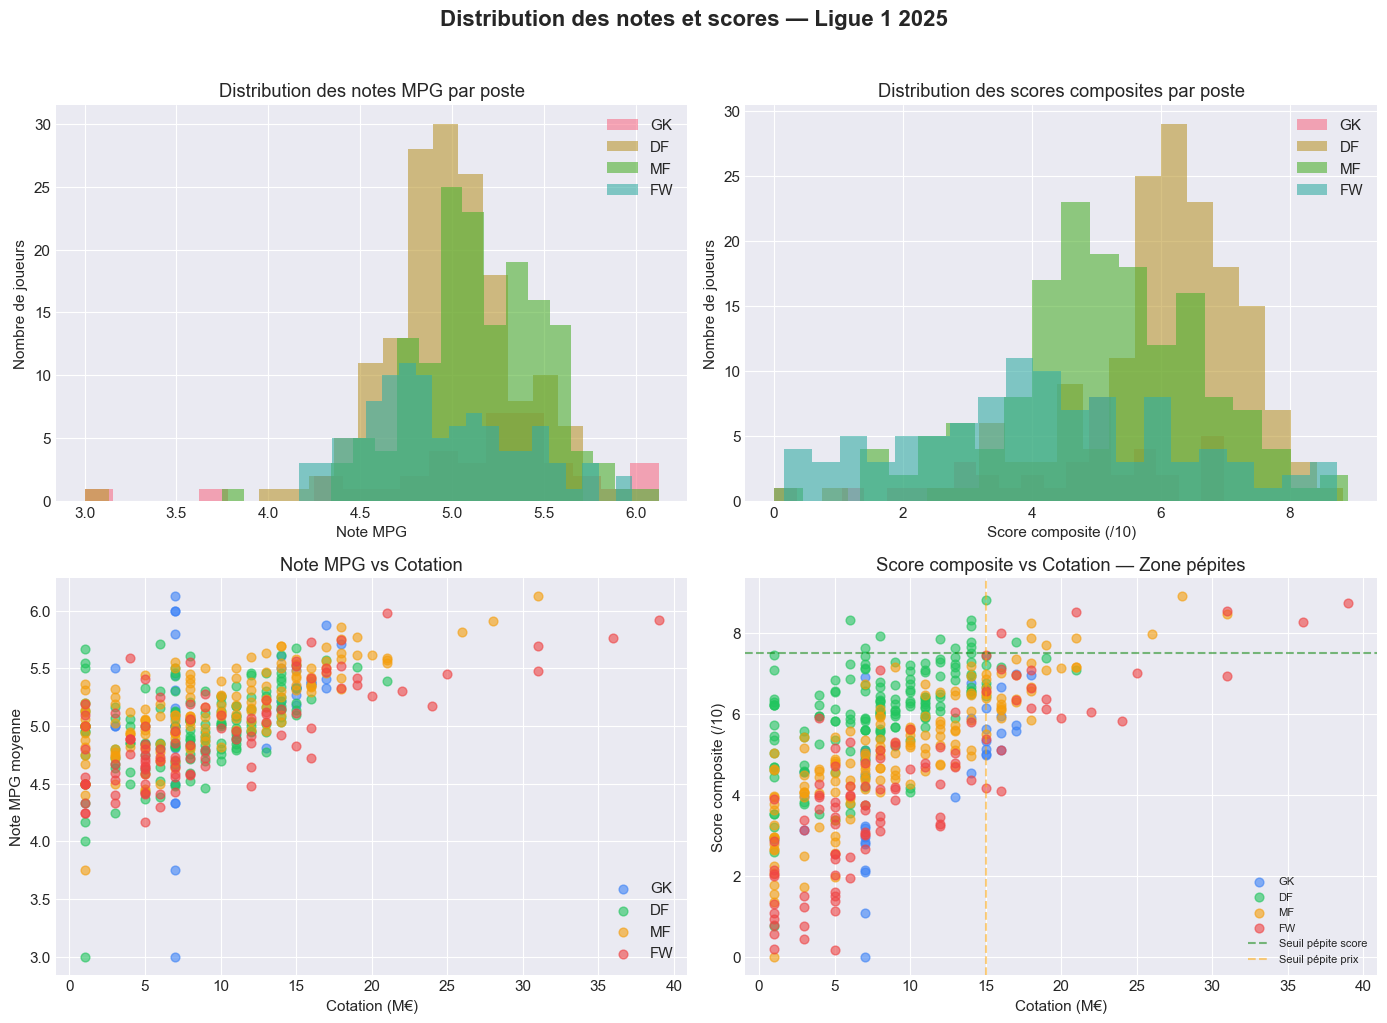

✅ Graphique sauvegardé dans notebooks/distributions.png


In [6]:
# ── Distribution des notes MPG et scores composites ─────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution des notes et scores — Ligue 1 2025', 
             fontsize=16, fontweight='bold', y=1.02)

# 1. Distribution des notes MPG par poste
ax1 = axes[0, 0]
for pos in ['GK', 'DF', 'MF', 'FW']:
    data = df_scored[df_scored['position'].str.startswith(pos)]['avg_rating'].dropna()
    if len(data) > 0:
        ax1.hist(data, bins=20, alpha=0.6, label=pos)
ax1.set_title('Distribution des notes MPG par poste')
ax1.set_xlabel('Note MPG')
ax1.set_ylabel('Nombre de joueurs')
ax1.legend()

# 2. Distribution des scores composites
ax2 = axes[0, 1]
for pos in ['GK', 'DF', 'MF', 'FW']:
    data = df_scored[df_scored['position'].str.startswith(pos)]['mpg_score'].dropna()
    if len(data) > 0:
        ax2.hist(data, bins=20, alpha=0.6, label=pos)
ax2.set_title('Distribution des scores composites par poste')
ax2.set_xlabel('Score composite (/10)')
ax2.set_ylabel('Nombre de joueurs')
ax2.legend()

# 3. Note MPG vs Prix (cotation)
ax3 = axes[1, 0]
colors = {'GK': '#3b82f6', 'DF': '#22c55e', 'MF': '#f59e0b', 'FW': '#ef4444'}
for pos in ['GK', 'DF', 'MF', 'FW']:
    subset = df_scored[df_scored['position'].str.startswith(pos)]
    ax3.scatter(subset['price'], subset['avg_rating'], 
                alpha=0.6, label=pos, color=colors[pos], s=40)
ax3.set_title('Note MPG vs Cotation')
ax3.set_xlabel('Cotation (M€)')
ax3.set_ylabel('Note MPG moyenne')
ax3.legend()

# 4. Score composite vs Prix — zone pépites
ax4 = axes[1, 1]
for pos in ['GK', 'DF', 'MF', 'FW']:
    subset = df_scored[df_scored['position'].str.startswith(pos)]
    ax4.scatter(subset['price'], subset['mpg_score'],
                alpha=0.6, label=pos, color=colors[pos], s=40)
# Zone pépite : bon score, petit prix
ax4.axhline(y=7.5, color='green', linestyle='--', alpha=0.5, label='Seuil pépite score')
ax4.axvline(x=15, color='orange', linestyle='--', alpha=0.5, label='Seuil pépite prix')
ax4.set_title('Score composite vs Cotation — Zone pépites')
ax4.set_xlabel('Cotation (M€)')
ax4.set_ylabel('Score composite (/10)')
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé dans notebooks/distributions.png")

In [7]:
# ── Top joueurs par poste ────────────────────────────────────

# Dictionnaire clubs pour affichage lisible
CLUBS = {
    "mpg_championship_club_138":  "Auxerre",
    "mpg_championship_club_141":  "Le Havre",
    "mpg_championship_club_142":  "Lens",
    "mpg_championship_club_143":  "Lyon",
    "mpg_championship_club_144":  "Marseille",
    "mpg_championship_club_145":  "Metz",
    "mpg_championship_club_146":  "Monaco",
    "mpg_championship_club_147":  "Montpellier",
    "mpg_championship_club_149":  "PSG",
    "mpg_championship_club_150":  "Rennes",
    "mpg_championship_club_152":  "Saint-Étienne",
    "mpg_championship_club_153":  "Strasbourg",
    "mpg_championship_club_429":  "Lille",
    "mpg_championship_club_427":  "Toulouse",
    "mpg_championship_club_430":  "Nantes",
    "mpg_championship_club_694":  "Lorient",
    "mpg_championship_club_862":  "Brest",
    "mpg_championship_club_1395": "Nice",
    "mpg_championship_club_1423": "Reims",
    "mpg_championship_club_2128": "Angers",
    "mpg_championship_club_2338": "Paris FC",
}
df_scored['club'] = df_scored['team'].map(CLUBS).fillna(df_scored['team'])

print("=" * 65)
for pos, label in [("GK", "GARDIENS"), ("DF", "DÉFENSEURS"), 
                    ("MF", "MILIEUX"),  ("FW", "ATTAQUANTS")]:
    print(f"\n🏆 TOP 8 {label}")
    print("-" * 65)
    top = (
        df_scored[df_scored['position'].str.startswith(pos)]
        .nlargest(8, 'mpg_score')
        [['player_name', 'first_name', 'club', 'avg_rating', 
          'recent_form_avg', 'mpg_score', 'price']]
    )
    top['Joueur'] = top['first_name'].fillna('') + ' ' + top['player_name']
    top['Joueur'] = top['Joueur'].str.strip()
    top = top.rename(columns={
        'avg_rating': 'Note', 'recent_form_avg': 'Forme',
        'mpg_score': 'Score', 'price': 'Prix'
    })
    print(top[['Joueur', 'club', 'Note', 'Forme', 'Score', 'Prix']].to_string(index=False))


🏆 TOP 8 GARDIENS
-----------------------------------------------------------------
         Joueur      club     Note  Forme  Score  Prix
    Hervé Koffi    Angers 5.879310   5.90   6.98    17
  Dominik Greif      Lyon 5.714286   6.10   6.97    18
Patrik Carlgren    Nantes 6.000000   8.00   6.92     7
 Matvey Safonov       PSG 5.607143   6.33   6.77    14
     Berke Özer     Lille 5.387097   5.70   6.67    16
   Robin Risser      Lens 5.484848   4.40   6.14    15
    Brice Samba    Rennes 5.359375   5.70   5.95    16
 Gerónimo Rulli Marseille 5.500000   5.00   5.89    14

🏆 TOP 8 DÉFENSEURS
-----------------------------------------------------------------
        Joueur       club     Note  Forme  Score  Prix
   Nuno Mendes        PSG 5.675000   6.00   8.83    15
    Bryan Okoh    Auxerre 5.615385   5.60   8.32    14
       Beraldo        PSG 5.710526   5.80   8.32     6
Romain Perraud      Lille 5.413793   6.20   8.17    14
 Samson Baidoo       Lens 5.608696   5.20   7.92     8
 Dieg

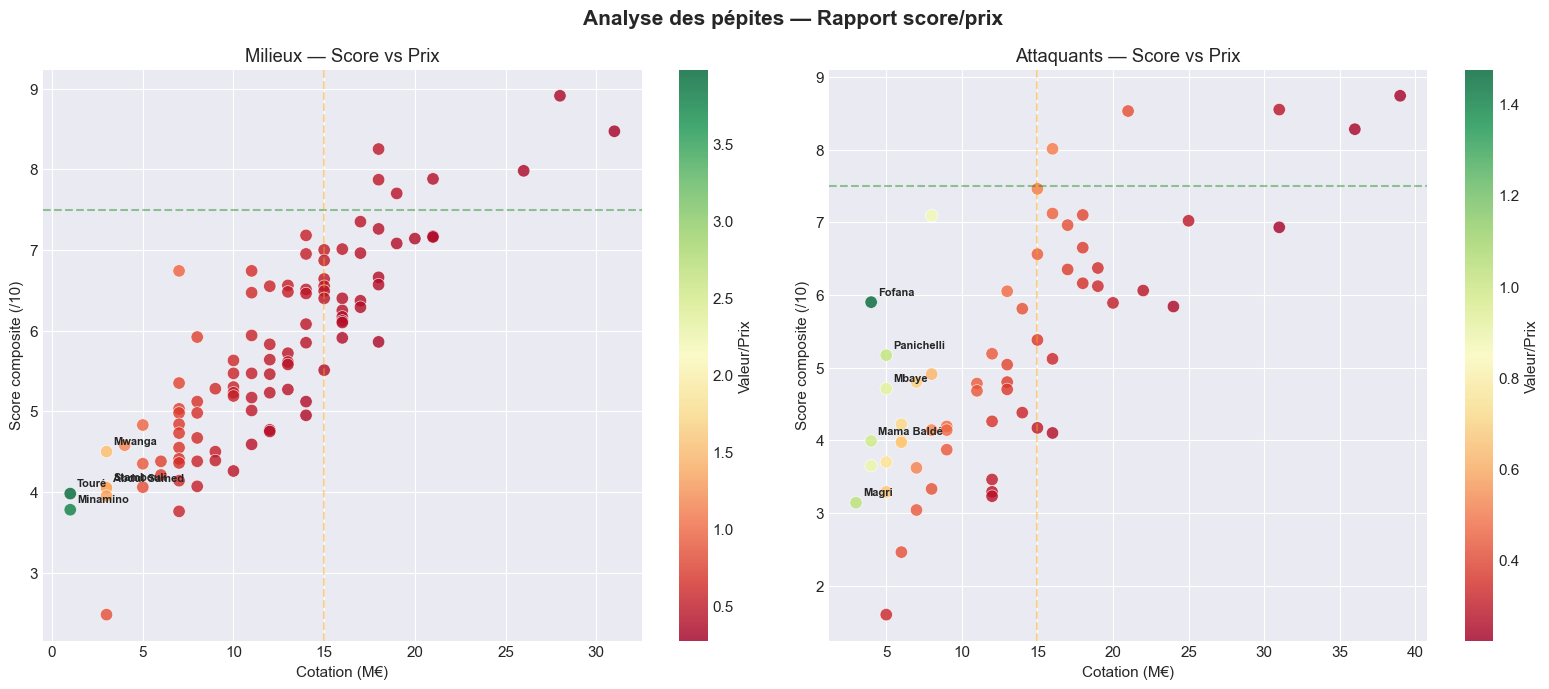


🔥 TOP 5 PÉPITES PAR POSTE (min. 8 matchs titulaire)

── Défenseurs ──
   Joueur    club  Score  Prix  Valeur/Prix  Forme
  Le Bris Lorient   7.09     1         7.09    5.0
   Gradit    Lens   5.45     1         5.45    NaN
Sierralta Auxerre   4.69     1         4.69    NaN
  Jacquet  Rennes   4.68     1         4.68    NaN
   Salisu  Monaco   4.61     1         4.61    NaN

── Milieux ──
     Joueur       club  Score  Prix  Valeur/Prix  Forme
      Touré   Le Havre   3.98     1        3.980    NaN
   Minamino     Monaco   3.78     1        3.780    NaN
     Mwanga Strasbourg   4.50     3        1.500   3.75
  Stambouli       Metz   4.06     3        1.353   4.88
Abdul Samed       Nice   4.05     3        1.350   4.62

── Attaquants ──
    Joueur       club  Score  Prix  Valeur/Prix  Forme
    Fofana       Lyon   5.90     4        1.475   4.50
     Magri   Toulouse   3.14     3        1.047    NaN
Panichelli Strasbourg   5.17     5        1.034    NaN
Mama Baldé      Brest   3.99     4

In [8]:
# ── Analyse des pépites ──────────────────────────────────────
df_pepites = df_scored[
    df_scored['started_matches'] >= 8
].copy()
df_pepites['value_score'] = (df_pepites['mpg_score'] / df_pepites['price'].replace(0, np.nan)).round(3)
df_pepites['club'] = df_pepites['team'].map(CLUBS).fillna(df_pepites['team'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Analyse des pépites — Rapport score/prix', fontsize=15, fontweight='bold')

for ax, pos, label, color in [
    (axes[0], 'MF', 'Milieux', '#f59e0b'),
    (axes[1], 'FW', 'Attaquants', '#ef4444'),
]:
    subset = df_pepites[df_pepites['position'].str.startswith(pos)].dropna(subset=['value_score'])
    
    sc = ax.scatter(
        subset['price'], subset['mpg_score'],
        c=subset['value_score'], cmap='RdYlGn',
        s=80, alpha=0.8, edgecolors='white', linewidth=0.5
    )
    plt.colorbar(sc, ax=ax, label='Valeur/Prix')
    
    # Annoter les top 5 pépites
    top5 = subset.nlargest(5, 'value_score')
    for _, row in top5.iterrows():
        ax.annotate(
            row['player_name'],
            (row['price'], row['mpg_score']),
            textcoords="offset points", xytext=(5, 5),
            fontsize=8, fontweight='bold'
        )
    
    # Zones de référence
    ax.axhline(y=7.5, color='green', linestyle='--', alpha=0.4)
    ax.axvline(x=15, color='orange', linestyle='--', alpha=0.4)
    ax.set_title(f'{label} — Score vs Prix')
    ax.set_xlabel('Cotation (M€)')
    ax.set_ylabel('Score composite (/10)')

plt.tight_layout()
plt.savefig('notebooks/pepites.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 5 pépites par poste
print("\n🔥 TOP 5 PÉPITES PAR POSTE (min. 8 matchs titulaire)\n")
for pos, label in [("DF","Défenseurs"), ("MF","Milieux"), ("FW","Attaquants")]:
    print(f"── {label} ──")
    top = (
        df_pepites[df_pepites['position'].str.startswith(pos) & (df_pepites['price'] <= 20)]
        .nlargest(5, 'value_score')
        [['player_name', 'club', 'mpg_score', 'price', 'value_score', 'recent_form_avg']]
        .rename(columns={'player_name':'Joueur','mpg_score':'Score',
                         'price':'Prix','value_score':'Valeur/Prix','recent_form_avg':'Forme'})
    )
    print(top.to_string(index=False))
    print()

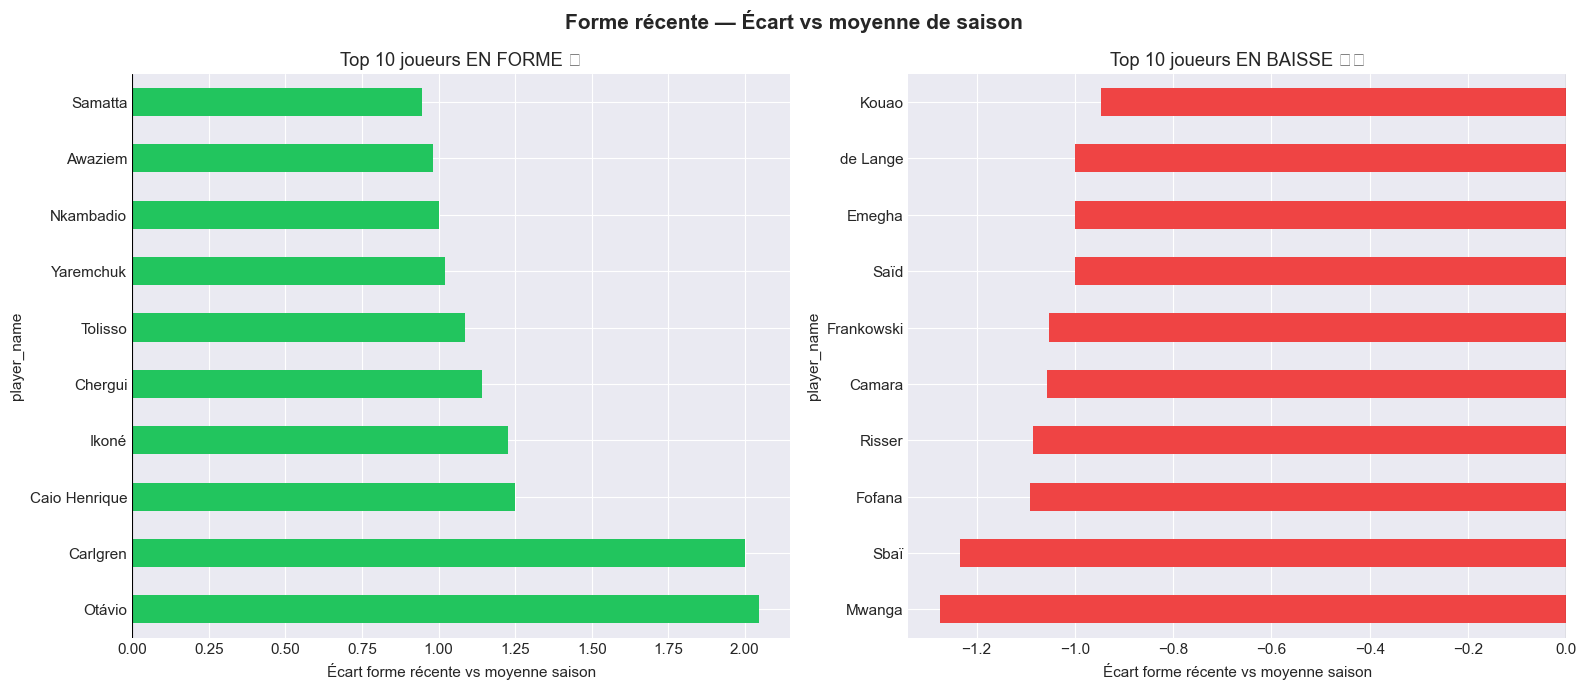


🔥 TOP 10 EN FORME (toutes positions, min 10 matchs)
------------------------------------------------------------
       Joueur     club Poste     Moy.  Forme    Écart  Prix
       Otávio Paris FC    DF 4.954545   7.00 2.045455     7
     Carlgren   Nantes    GK 6.000000   8.00 2.000000     7
Caio Henrique   Monaco    DF 4.750000   6.00 1.250000     5
        Ikoné Paris FC    MF 5.022727   6.25 1.227273    13
      Chergui Paris FC    DF 4.857143   6.00 1.142857     5
      Tolisso     Lyon    MF 5.913793   7.00 1.086207    28
    Yaremchuk     Lyon    FW 5.100000   6.12 1.020000    10
    Nkambadio Paris FC    GK 5.000000   6.00 1.000000     7
      Awaziem   Nantes    DF 5.019231   6.00 0.980769    10
      Samatta Le Havre    FW 4.653846   5.60 0.946154     9


In [9]:
# ── Forme récente vs moyenne de saison ──────────────────────
df_forme = df_scored[
    df_scored['recent_form_avg'].notna() &
    df_scored['avg_rating'].notna() &
    (df_scored['games_played'] >= 10)
].copy()

df_forme['delta'] = df_forme['recent_form_avg'] - df_forme['avg_rating']
df_forme['club']  = df_forme['team'].map(CLUBS).fillna(df_forme['team'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Forme récente — Écart vs moyenne de saison', fontsize=15, fontweight='bold')

# Graphique 1 : Top en forme vs en baisse
ax1 = axes[0]
top_forme = df_forme.nlargest(10, 'delta')[['player_name', 'delta', 'position']].set_index('player_name')
colors_bar = ['#22c55e' if d > 0 else '#ef4444' for d in top_forme['delta']]
top_forme['delta'].plot(kind='barh', ax=ax1, color=colors_bar)
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.set_title('Top 10 joueurs EN FORME 🔥')
ax1.set_xlabel('Écart forme récente vs moyenne saison')

# Graphique 2 : En baisse
ax2 = axes[1]
bot_forme = df_forme.nsmallest(10, 'delta')[['player_name', 'delta']].set_index('player_name')
bot_forme['delta'].plot(kind='barh', ax=ax2, color='#ef4444')
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_title('Top 10 joueurs EN BAISSE ❄️')
ax2.set_xlabel('Écart forme récente vs moyenne saison')

plt.tight_layout()
plt.savefig('notebooks/forme.png', dpi=150, bbox_inches='tight')
plt.show()

# Tableau détaillé
print("\n🔥 TOP 10 EN FORME (toutes positions, min 10 matchs)")
print("-" * 60)
top10 = df_forme.nlargest(10, 'delta')[
    ['player_name', 'club', 'position', 'avg_rating', 'recent_form_avg', 'delta', 'price']
].rename(columns={
    'player_name':'Joueur', 'position':'Poste',
    'avg_rating':'Moy.', 'recent_form_avg':'Forme', 
    'delta':'Écart', 'price':'Prix'
})
print(top10.to_string(index=False))

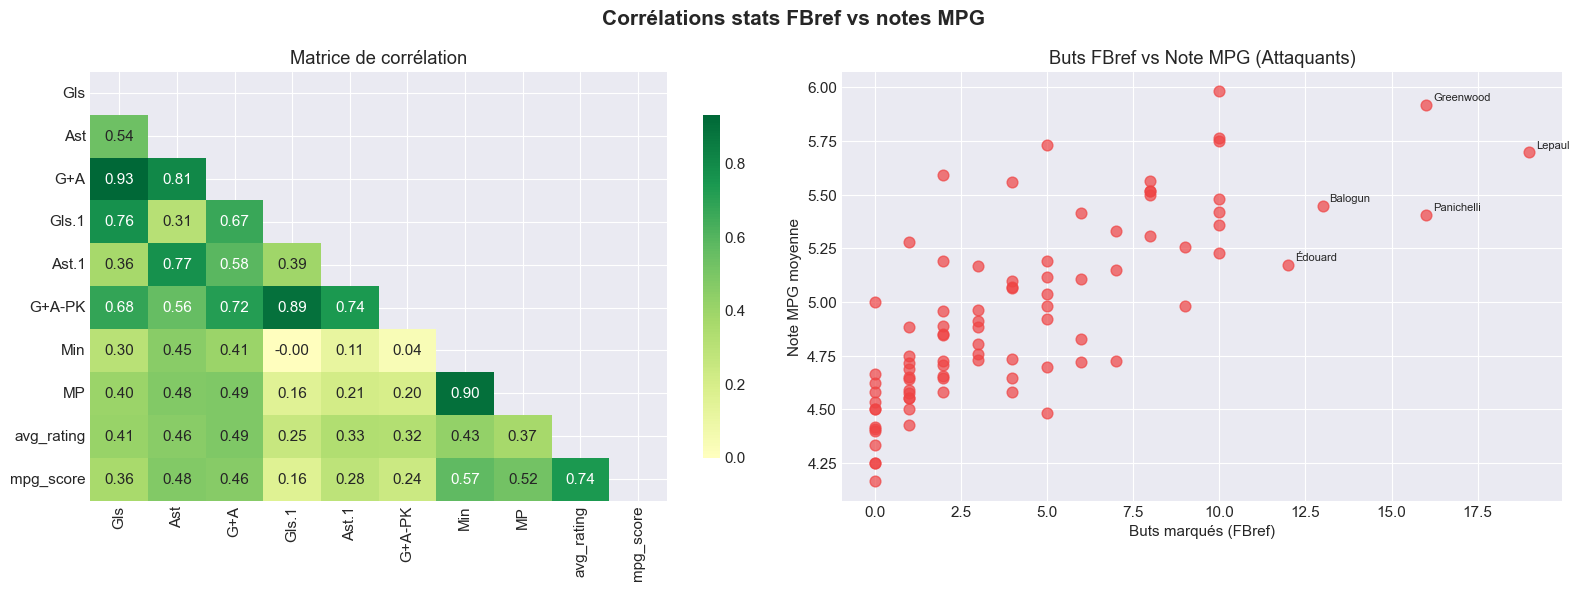


📊 Stats FBref les plus corrélées avec la note MPG :
G+A       0.485314
Ast       0.456794
Min       0.426789
Gls       0.412019
MP        0.367841
Ast.1     0.332075
G+A-PK    0.322985
Gls.1     0.251319


In [11]:
# ── Corrélations entre stats FBref et note MPG ──────────────
df_fbref = df_scored[df_scored['Gls'].notna()].copy()
df_fbref['club'] = df_fbref['team'].map(CLUBS).fillna(df_fbref['team'])

# Nettoyer les colonnes numériques (supprimer les virgules des milliers)
fbref_stats = ['Gls', 'Ast', 'G+A', 'Gls.1', 'Ast.1', 'G+A-PK', 'Min', 'MP']
fbref_stats = [c for c in fbref_stats if c in df_fbref.columns]

for col in fbref_stats:
    df_fbref[col] = df_fbref[col].astype(str).str.replace(',', '', regex=False)
    df_fbref[col] = pd.to_numeric(df_fbref[col], errors='coerce')

# Corrélation avec avg_rating
corr_rating = df_fbref[fbref_stats + ['avg_rating', 'mpg_score']].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Corrélations stats FBref vs notes MPG', fontsize=15, fontweight='bold')

# Heatmap corrélations
mask = np.zeros_like(corr_rating, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_rating, ax=axes[0],
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, mask=mask,
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Matrice de corrélation')

# Buts FBref vs Note MPG (attaquants)
fw = df_fbref[df_fbref['position'].str.startswith('FW')].dropna(subset=['Gls', 'avg_rating'])
axes[1].scatter(fw['Gls'], fw['avg_rating'], alpha=0.7, color='#ef4444', s=60)
for _, row in fw.nlargest(5, 'Gls').iterrows():
    axes[1].annotate(row['player_name'], (row['Gls'], row['avg_rating']),
                     textcoords="offset points", xytext=(5,3), fontsize=8)
axes[1].set_title('Buts FBref vs Note MPG (Attaquants)')
axes[1].set_xlabel('Buts marqués (FBref)')
axes[1].set_ylabel('Note MPG moyenne')

plt.tight_layout()
plt.savefig('notebooks/correlations.png', dpi=150, bbox_inches='tight')
plt.show()

corr_with_rating = df_fbref[fbref_stats].corrwith(df_fbref['avg_rating']).abs().sort_values(ascending=False)
print("\n📊 Stats FBref les plus corrélées avec la note MPG :")
print(corr_with_rating.to_string())

In [12]:
# ── Synthèse finale ──────────────────────────────────────────
print("=" * 65)
print("  SYNTHÈSE — INSIGHTS CLÉS POUR MPG")
print("=" * 65)

print("""
📊 CORRÉLATIONS (ce qui prédit le mieux la note MPG) :
  → G+A (buts+passes) : corrélation 0.49 — stat la plus prédictive
  → Minutes jouées    : corrélation 0.43 — logique (plus on joue, mieux noté)
  → Buts seuls        : corrélation 0.41

💡 IMPLICATION POUR LE SCORING :
  → Les poids actuels de player_rating.py sont validés
  → Intégrer G+A dans le score des MF/FW améliorerait la précision
""")

# Meilleur rapport qualité/prix par poste
print("💎 MEILLEURES AFFAIRES DU MOMENT (score élevé, prix raisonnable) :")
print("-" * 65)
for pos, label, max_p in [("DF","Défenseurs",15), ("MF","Milieux",20), ("FW","Attaquants",22)]:
    best = (
        df_scored[
            df_scored['position'].str.startswith(pos) &
            (df_scored['price'] <= max_p) &
            (df_scored['price'] >= 5) &
            (df_scored['started_matches'] >= 8)
        ]
        .nlargest(3, 'mpg_score')
        [['player_name', 'club', 'avg_rating', 'recent_form_avg', 'mpg_score', 'price']]
    )
    best['Joueur'] = best['player_name']
    print(f"\n  {label} (max {max_p}M€) :")
    for _, r in best.iterrows():
        forme_str = f"forme {r['recent_form_avg']:.1f}" if pd.notna(r['recent_form_avg']) else "forme N/A"
        print(f"    → {r['player_name']} ({r['club']}) — score {r['mpg_score']:.2f}, {forme_str}, {r['price']}M€")

print("\n" + "=" * 65)
print("  FIN DE L'ANALYSE — notebook prêt à committer ✅")
print("=" * 65)

  SYNTHÈSE — INSIGHTS CLÉS POUR MPG

📊 CORRÉLATIONS (ce qui prédit le mieux la note MPG) :
  → G+A (buts+passes) : corrélation 0.49 — stat la plus prédictive
  → Minutes jouées    : corrélation 0.43 — logique (plus on joue, mieux noté)
  → Buts seuls        : corrélation 0.41

💡 IMPLICATION POUR LE SCORING :
  → Les poids actuels de player_rating.py sont validés
  → Intégrer G+A dans le score des MF/FW améliorerait la précision

💎 MEILLEURES AFFAIRES DU MOMENT (score élevé, prix raisonnable) :
-----------------------------------------------------------------

  Défenseurs (max 15M€) :
    → Nuno Mendes (PSG) — score 8.83, forme 6.0, 15M€
    → Okoh (Auxerre) — score 8.32, forme 5.6, 14M€
    → Beraldo (PSG) — score 8.32, forme 5.8, 6M€

  Milieux (max 20M€) :
    → Kebbal (Paris FC) — score 8.25, forme 5.8, 18M€
    → Haraldsson (Lille) — score 7.87, forme 6.2, 18M€
    → João Neves (PSG) — score 7.70, forme 5.5, 19M€

  Attaquants (max 22M€) :
    → Pagis (Lorient) — score 8.53, forme